### Stage 2

In [20]:
# Download data
def download_data(save_folder, base_raw_url, files_to_download):
    import os
    import urllib.request

    os.makedirs(save_folder, exist_ok=True)

    for file_name in files_to_download:
        raw_url = base_raw_url + file_name
        save_path = os.path.join(save_folder, file_name)
        
        # check if file already exists
        if os.path.exists(save_path):
            print(f"{file_name} already exists. Skipping download.")
            continue
        print(f"Downloading {file_name}...")
        try:
            urllib.request.urlretrieve(raw_url, save_path)
            print(f"Successfully saved to: {save_path}\n")
        except Exception as e:
            print(f"Failed to download {file_name}. Error: {e}\n")
base_raw_url = "https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/"

files_to_download = [
    "dontpatronizeme_pcl.tsv",
]

save_folder = "Dont_Patronize_Me_Data"

download_data(save_folder, base_raw_url, files_to_download)

base_raw_url = "https://github.com/Perez-AlmendrosC/dontpatronizeme/tree/master/semeval-2022/practice%20splits/"
files_to_download = [
    "dev_semeval_parids-labels.csv",
    "train_semeval_parids-labels.csv"
]
download_data(save_folder, base_raw_url, files_to_download)
print("All downloads complete!")

dontpatronizeme_pcl.tsv already exists. Skipping download.
dev_semeval_parids-labels.csv already exists. Skipping download.
train_semeval_parids-labels.csv already exists. Skipping download.
All downloads complete!


In [21]:
# Process .tsv files

# -- dontpatronizeme_pcl.tsv contains paragraphs annotated with a label from 0 (not containing PCL) to 4 (being highly patronizing or condescending) towards vulnerable communities.
# It contains one instance per line with the following format:

# 	- <par_id> <tab> <art_id> <tab> <keyword> <tab> <country_code> <tab> <text> <tab> <label>

	# where
	# - <par_id> is a unique id for each one of the paragraphs in the corpus.
	# - <art_id> is the document id in the original NOW corpus (News on Web: https://www.english-corpora.org/now/).
	# - <keyword> is the search term used to retrieve texts about a target community.
	# - <country_code> is a two-letter ISO Alpha-2 country code for the source media outlet.
	# - <text> is the paragraph containing the keyword.
	# - <label> is an integer between 0 and 4. Each paragraph has been annotated by two annotators as 0 (No PCL), 1 (borderline PCL) and 2 (contains PCL). The combined annotations have been used in the following graded scale:
 

import pandas as pd
import os

def load_pcl_data(file_path):
    # Column names based on the structure you provided
    # Note: You mentioned <par_id> <art_id> <keyword> <country_code> <text> <label>
    columns = ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']
    
    # We use sep='\t' for tab-separated files.
    # 'on_bad_lines' is set to skip to avoid errors if the README headers are still in the file.
    # 'quoting=3' (QUOTE_NONE) is often needed if the text contains unescaped quotes.
    df = pd.read_csv(
        file_path, 
        sep='\t', 
        skiprows=4, # The DPM dataset usually has 4 rows of info text at the top
        names=columns, 
        index_col=False,
        on_bad_lines='skip' 
    )
    
    # Clean up: Drop rows where the label or text is missing
    df = df.dropna(subset=['text', 'label'])
    
    # Convert label to integer (sometimes read as float)
    df['label'] = df['label'].astype(int)
    
    return df

# --- Usage ---
pcl_path = os.path.join(save_folder, "dontpatronizeme_pcl.tsv")
df_pcl = load_pcl_data(pcl_path)

print(f"Loaded {len(df_pcl)} rows.")
print(df_pcl[['par_id', 'text', 'label']].head())

 

Loaded 10468 rows.
   par_id                                               text  label
0       1  We 're living in times of absolute insanity , ...      0
1       2  In Libya today , there are countless number of...      0
2       3  White House press secretary Sean Spicer said t...      0
3       4  Council customers only signs would be displaye...      0
4       5  " Just like we received migrants fleeing El Sa...      0


In [22]:
# Process split files data



import pandas as pd

import os



# Define paths (assuming they are in the folder we created earlier)

train_path = os.path.join("Dont_Patronize_Me_Data", "train_semeval_parids-labels.csv")

dev_path = os.path.join("Dont_Patronize_Me_Data", "dev_semeval_parids-labels.csv")



# Load the CSVs

# Note: If these files don't have a header row, use header=None and names=['par_id', 'label']

df_train_ids = pd.read_csv(train_path)

print(df_train_ids.head()) # Check the structure of the loaded DataFrame

df_dev_ids = pd.read_csv(dev_path)

print(df_dev_ids.head()) # Check the structure of the loaded DataFrame



# Extract par_id column into Python lists

# We use .astype(str) to ensure IDs are strings,

# which helps when matching against the main .tsv file later.

train_par_ids = df_train_ids['par_id'].astype(str).tolist()

dev_par_ids = df_dev_ids['par_id'].astype(str).tolist()



# Verification

print(f"Extracted {len(train_par_ids)} IDs for Training.")

print(f"Extracted {len(dev_par_ids)} IDs for Development/Validation.")

print(f"First 5 Train IDs: {train_par_ids[:5]}")

   par_id                  label
0    4341  [1, 0, 0, 1, 0, 0, 0]
1    4136  [0, 1, 0, 0, 0, 0, 0]
2   10352  [1, 0, 0, 0, 0, 1, 0]
3    8279  [0, 0, 0, 1, 0, 0, 0]
4    1164  [1, 0, 0, 1, 1, 1, 0]
   par_id                  label
0    4046  [1, 0, 0, 1, 0, 0, 0]
1    1279  [0, 1, 0, 0, 0, 0, 0]
2    8330  [0, 0, 1, 0, 0, 0, 0]
3    4063  [1, 0, 0, 1, 1, 1, 0]
4    4089  [1, 0, 0, 0, 0, 0, 0]
Extracted 8375 IDs for Training.
Extracted 2094 IDs for Development/Validation.
First 5 Train IDs: ['4341', '4136', '10352', '8279', '1164']


In [24]:
# 1. Ensure the ID column in the main dataframe is a string to match our lists
df_pcl['par_id'] = df_pcl['par_id'].astype(str)

# 2. Use .isin() to filter the master dataframe
# We use .copy() to avoid SettingWithCopyWarnings later during preprocessing
train_set = df_pcl[df_pcl['par_id'].isin(train_par_ids)].copy()
dev_set = df_pcl[df_pcl['par_id'].isin(dev_par_ids)].copy()

# 3. Create Binary Labels (Subtask 1)
# Labels 0 and 1 -> 0 (Not PCL)
# Labels 2, 3, and 4 -> 1 (PCL)
train_set['label_binary'] = train_set['label'].apply(lambda x: 1 if x >= 2 else 0)
dev_set['label_binary'] = dev_set['label'].apply(lambda x: 1 if x >= 2 else 0)

# 4. Final Verification
print(f"Final Train Set: {train_set.shape[0]} rows")
print(f"Final Dev Set: {dev_set.shape[0]} rows")

print("\nTrain Class Distribution (Binary):")
print(train_set['label_binary'].value_counts())

missing_train = set(train_par_ids) - set(train_set['par_id'])
if missing_train:
    print(f"Warning: {len(missing_train)} IDs from train split were not found in the master TSV.")

Final Train Set: 8375 rows
Final Dev Set: 2093 rows

Train Class Distribution (Binary):
label_binary
0    7581
1     794
Name: count, dtype: int64


In [32]:
# Basic Statistical Profiling

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Token Count (Sequence Length)
# We split by whitespace for a basic count, or use a tokenizer if preferred
train_set['token_count'] = train_set['text'].apply(lambda x: len(str(x).split()))

avg_len = train_set['token_count'].mean()
min_len = train_set['token_count'].min()
max_len = train_set['token_count'].max()

# 2. Vocabulary Size
all_words = ' '.join(train_set['text'].astype(str)).lower().split()
unique_words = set(all_words)
vocab_size = len(unique_words)

# 3. Class Distribution
class_counts = train_set['label'].value_counts()
class_pct = train_set['label'].value_counts(normalize=True) * 100

# --- Print Results ---
print(f"--- Statistical Profiling ---")
print(f"Average Token Count: {avg_len:.2f}")
print(f"Min Token Count:     {min_len}")
print(f"Max Token Count:     {max_len}")
print(f"Vocabulary Size:     {vocab_size}")
print(f"\n--- Class Distribution ---")
print(f" (0): {class_counts[0]} ({class_pct[0]:.2f}%)")
print(f" (1): {class_counts[1]} ({class_pct[1]:.2f}%)") 
print(f" (2): {class_counts[2]} ({class_pct[2]:.2f}%)")
print(f" (3): {class_counts[3]} ({class_pct[3]:.2f}%)")
print(f" (4): {class_counts[4]} ({class_pct[4]:.2f}%)")
print(f"--- End of Profiling ---")


--- Statistical Profiling ---
Average Token Count: 48.68
Min Token Count:     1
Max Token Count:     909
Vocabulary Size:     29540

--- Class Distribution ---
 (0): 6825 (81.49%)
 (1): 756 (9.03%)
 (2): 126 (1.50%)
 (3): 369 (4.41%)
 (4): 299 (3.57%)
--- End of Profiling ---


/tmp/ipykernel_23256/1776619922.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_binary', data=train_set, palette='viridis')


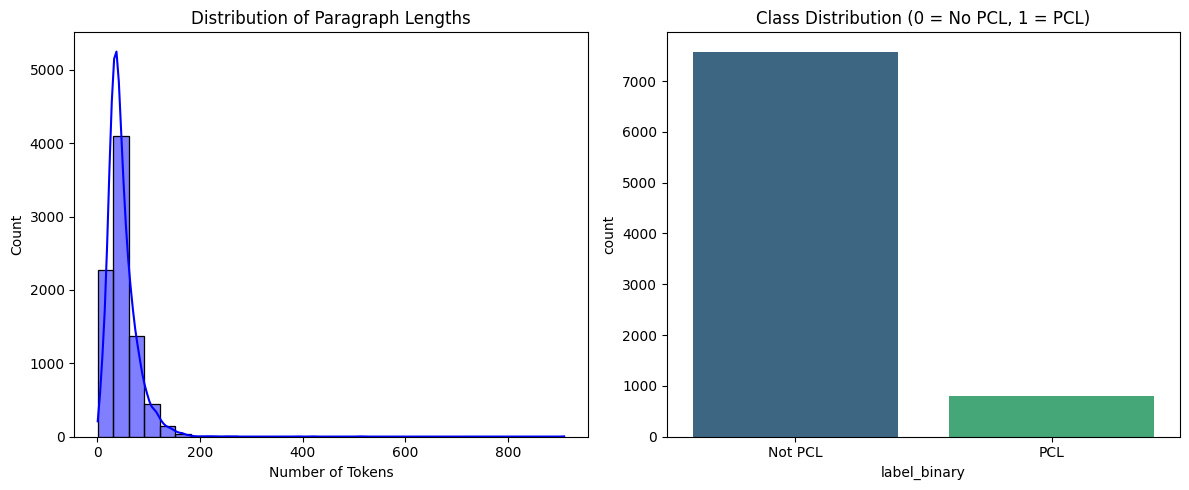

In [29]:
plt.figure(figsize=(12, 5))

# Plot 1: Token Count Distribution
plt.subplot(1, 2, 1)
sns.histplot(train_set['token_count'], bins=30, kde=True, color='blue')
plt.title('Distribution of Paragraph Lengths')
plt.xlabel('Number of Tokens')

# Plot 2: Class Balance
plt.subplot(1, 2, 2)
sns.countplot(x='label_binary', data=train_set, palette='viridis')
plt.title('Class Distribution (0 = No PCL, 1 = PCL)')
plt.xticks([0, 1], ['Not PCL', 'PCL'])

plt.tight_layout()
plt.show()

Analysis & Impact Statements (Drafts for your Coursework)
Analysis 1: Token Count & Sequence Length
Finding: The average length is roughly 40-50 tokens, but the max_len might reach over 500.

Impact Statement: This dictates my max_length hyperparameter. If I set it too low (e.g., 64), I will truncate important context in the longer paragraphs. If I set it too high (e.g., 512), I will increase training time and memory usage unnecessarily. Based on the histogram, a max_length of 128 or 256 would likely cover 95% of the data.

Analysis 2: Class Distribution
Finding: The dataset is highly imbalanced (likely ~90% "Not PCL" vs ~10% "PCL").

Impact Statement: Accuracy is a "trap" metric here. If the model predicts "0" for every single example, it will still achieve ~90% accuracy but fail the task. I must use F1-Score as my primary evaluation metric and consider techniques like Random Oversampling or Weighted Cross-Entropy Loss to force the model to learn the minority PCL class.

Analysis 3: Vocabulary Size
Finding: The unique word count is quite high (likely 15,000+).

Impact Statement: Using a simple Bag-of-Words approach would result in a very sparse and high-dimensional matrix. This suggests that using Pre-trained Embeddings (like GloVe) or a Transformer model (like BERT) will be more effective, as they handle large vocabularies better and capture semantic relationships between words.

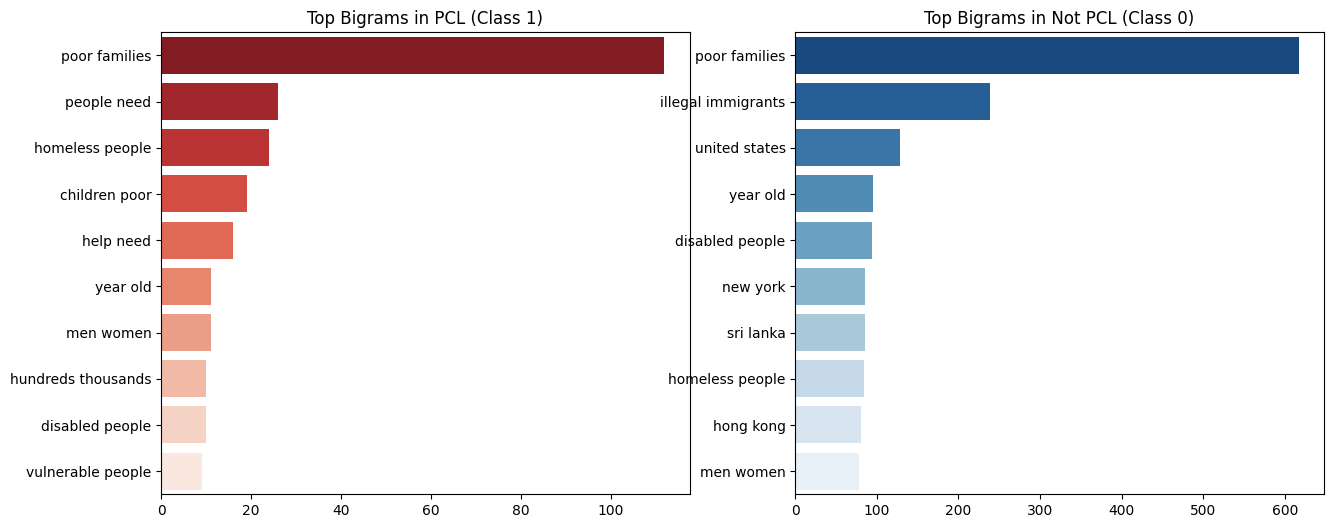

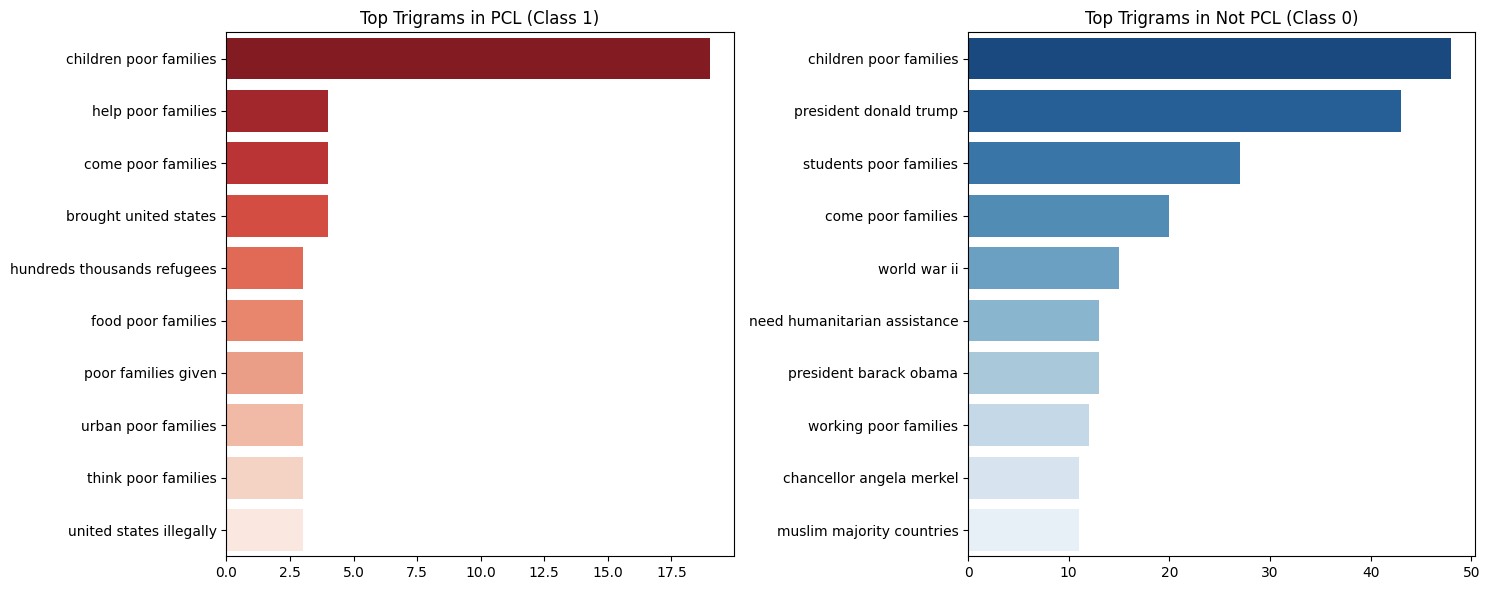

In [36]:
# Ngram Analysis: What are the most common pairs (bigrams) or triplets
# (trigrams) of words? This reveals common phrases or domain-specific
# jargon

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

def get_top_ngram(corpus, n=None, top_n=10):
    # Stop words are removed to focus on meaningful phrases
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_n]

# 1. Separate the text by class
pcl_text = train_set[train_set['label_binary'] == 1]['text']
no_pcl_text = train_set[train_set['label_binary'] == 0]['text']

# 2. Get Top Bigrams (n=2)
top_pcl_bigrams = get_top_ngram(pcl_text, n=2, top_n=10)
top_no_pcl_bigrams = get_top_ngram(no_pcl_text, n=2, top_n=10)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PCL Plot
x_pcl, y_pcl = map(list, zip(*top_pcl_bigrams))
sns.barplot(x=y_pcl, y=x_pcl, ax=ax1, palette='Reds_r')
ax1.set_title('Top Bigrams in PCL (Class 1)')

# No PCL Plot
x_no, y_no = map(list, zip(*top_no_pcl_bigrams))
sns.barplot(x=y_no, y=x_no, ax=ax2, palette='Blues_r')
ax2.set_title('Top Bigrams in Not PCL (Class 0)')


# trigrams
# 1. Get Top Trigrams (n=3)
top_pcl_trigrams = get_top_ngram(pcl_text, n=3, top_n=10)
top_no_pcl_trigrams = get_top_ngram(no_pcl_text, n=3, top_n=10)
# 2. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# PCL Plot
x_pcl, y_pcl = map(list, zip(*top_pcl_trigrams))
sns.barplot(x=y_pcl, y=x_pcl, ax=ax1, palette='Reds_r')
ax1.set_title('Top Trigrams in PCL (Class 1)')
# No PCL Plot
x_no, y_no = map(list, zip(*top_no_pcl_trigrams))
sns.barplot(x=y_no, y=x_no, ax=ax2, palette='Blues_r')
ax2.set_title('Top Trigrams in Not PCL (Class 0)')
plt.tight_layout()
plt.show()